### Lab 3 - Oscillator Simulations

**Student:** Zaki Daouk  
**Date:** 2026-9-13

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Part A — The Simple Harmonic Oscillator

In [ ]:
# Parameters
k = 1.0     # spring constant (N/m)
m = 1.0     # mass (kg)
omega0 = np.sqrt(k / m)   # natural frequency
T = 2 * np.pi / omega0      # period

# Initial conditions
x0 = 1.0    # initial displacement (m)
v0 = 0.0    # released from rest

# Exact solution for comparison
def exact_x(t):
    return x0 * np.cos(omega0 * t)

def exact_v(t):
    return -x0 * omega0 * np.sin(omega0 * t)

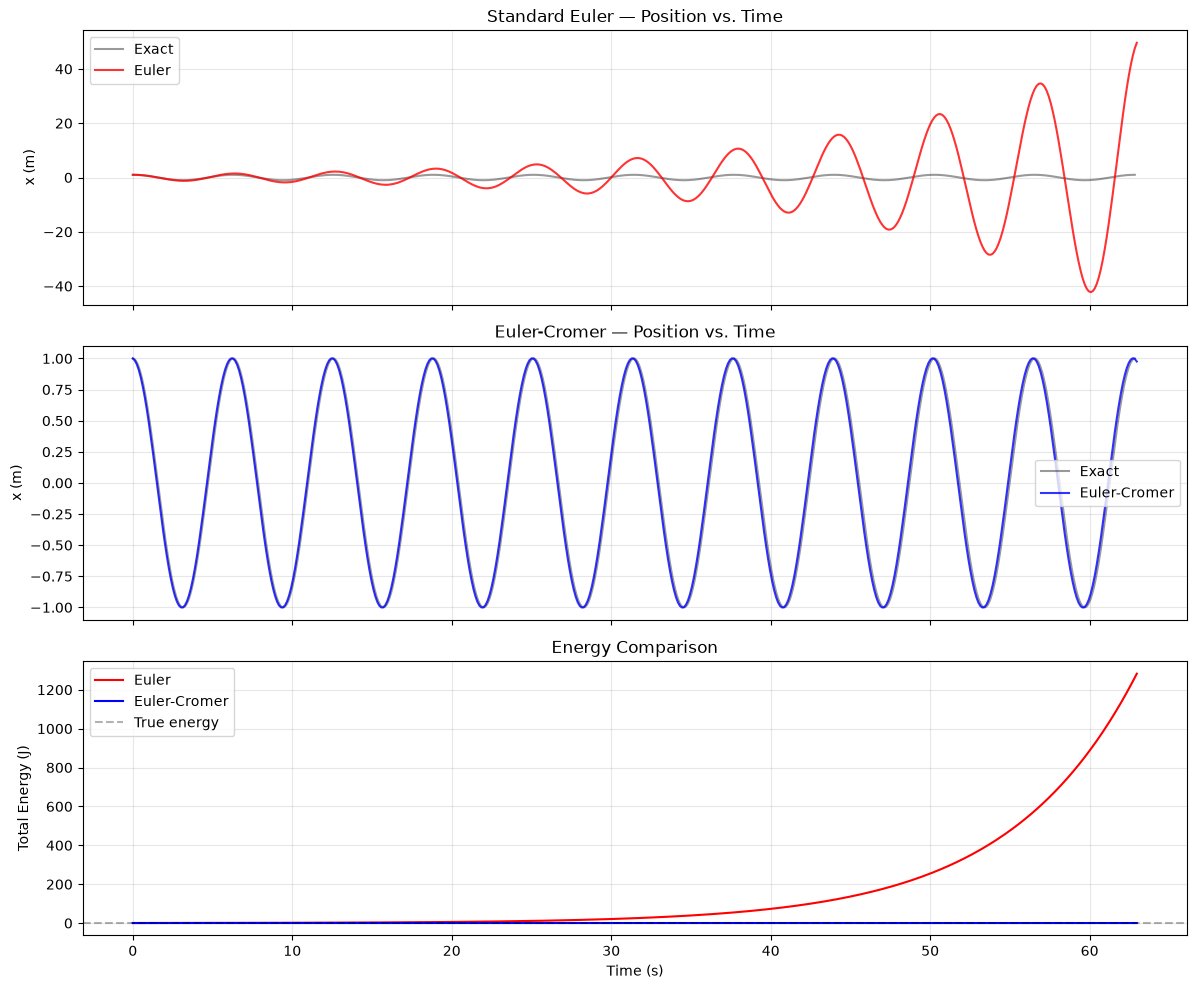

In [ ]:
def simulate_sho(method, dt, n_periods=10):
    """Simulate SHO. Returns t, x, v, E arrays."""
    t_max = n_periods * T
    x, v = x0, v0
    ts, xs, vs, Es = [0], [x], [v], [0.5*k*x**2 + 0.5*m*v**2]
    t = 0.0

    while t < t_max:
        a = -(k / m) * x

        if method == 'euler':
            x_new = x + v * dt
            v_new = v + a * dt
            x, v = x_new, v_new
        elif method == 'euler-cromer':
            v = v + a * dt       # velocity first
            x = x + v * dt       # then position with new v

        t += dt
        E = 0.5 * k * x**2 + 0.5 * m * v**2
        ts.append(t); xs.append(x); vs.append(v); Es.append(E)

    return np.array(ts), np.array(xs), np.array(vs), np.array(Es)

# Run both with dt = T/50 (moderately coarse)
dt = T / 50
t_e, x_e, v_e, E_e = simulate_sho('euler', dt)
t_ec, x_ec, v_ec, E_ec = simulate_sho('euler-cromer', dt)
t_exact = np.linspace(0, 10*T, 2000)

# ─── Plot: x(t) comparison ────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(t_exact, exact_x(t_exact), 'k-', alpha=0.4, label='Exact')
axes[0].plot(t_e, x_e, 'r-', alpha=0.8, label='Euler')
axes[0].set_ylabel('x (m)')
axes[0].set_title('Standard Euler — Position vs. Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_exact, exact_x(t_exact), 'k-', alpha=0.4, label='Exact')
axes[1].plot(t_ec, x_ec, 'b-', alpha=0.8, label='Euler-Cromer')
axes[1].set_ylabel('x (m)')
axes[1].set_title('Euler-Cromer — Position vs. Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_e, E_e, 'r-', label='Euler')
axes[2].plot(t_ec, E_ec, 'b-', label='Euler-Cromer')
axes[2].axhline(y=E_e[0], color='k', linestyle='--', alpha=0.3, label='True energy')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Total Energy (J)')
axes[2].set_title('Energy Comparison')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Part A Results and Discussion

The code simulates a simple harmonic oscillator using the standard Euler method and the Euler-Cromer method. It compares both numerical solutions with the exact solution and examines their total energy and phase-space trajectories.
The standard Euler method becomes increasingly inaccurate over time. Its total energy grows, causing the oscillation amplitude to increase and the phase-space trajectory to spiral outward. In contrast, Euler-Cromer keeps the energy bounded and produces a trajectory that remains close to the expected elliptical orbit. Therefore, Euler-Cromer provides a more stable and physically realistic simulation for oscillatory motion.

### Part B — Phase Space & Damped Oscillations
Visualization: B.1 — Phase-space portraits

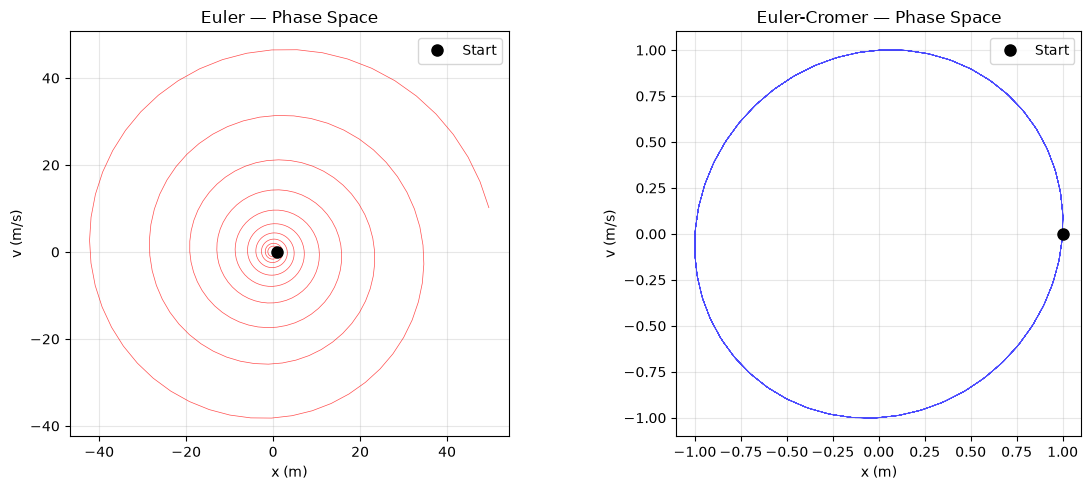

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Euler phase portrait
ax1.plot(x_e, v_e, 'r-', alpha=0.7, linewidth=0.5)
ax1.plot(x_e[0], v_e[0], 'ko', markersize=8, label='Start')
ax1.set_xlabel('x (m)'); ax1.set_ylabel('v (m/s)')
ax1.set_title('Euler — Phase Space')
ax1.set_aspect('equal')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Euler-Cromer phase portrait
ax2.plot(x_ec, v_ec, 'b-', alpha=0.7, linewidth=0.5)
ax2.plot(x_ec[0], v_ec[0], 'ko', markersize=8, label='Start')
ax2.set_xlabel('x (m)'); ax2.set_ylabel('v (m/s)')
ax2.set_title('Euler-Cromer — Phase Space')
ax2.set_aspect('equal')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

B.2 — Adding Damping: Oscillators lose energy with linear damping force that is properotional to velocity. F = −kx − bv    →    a = −(k/m) x − (b/m) v

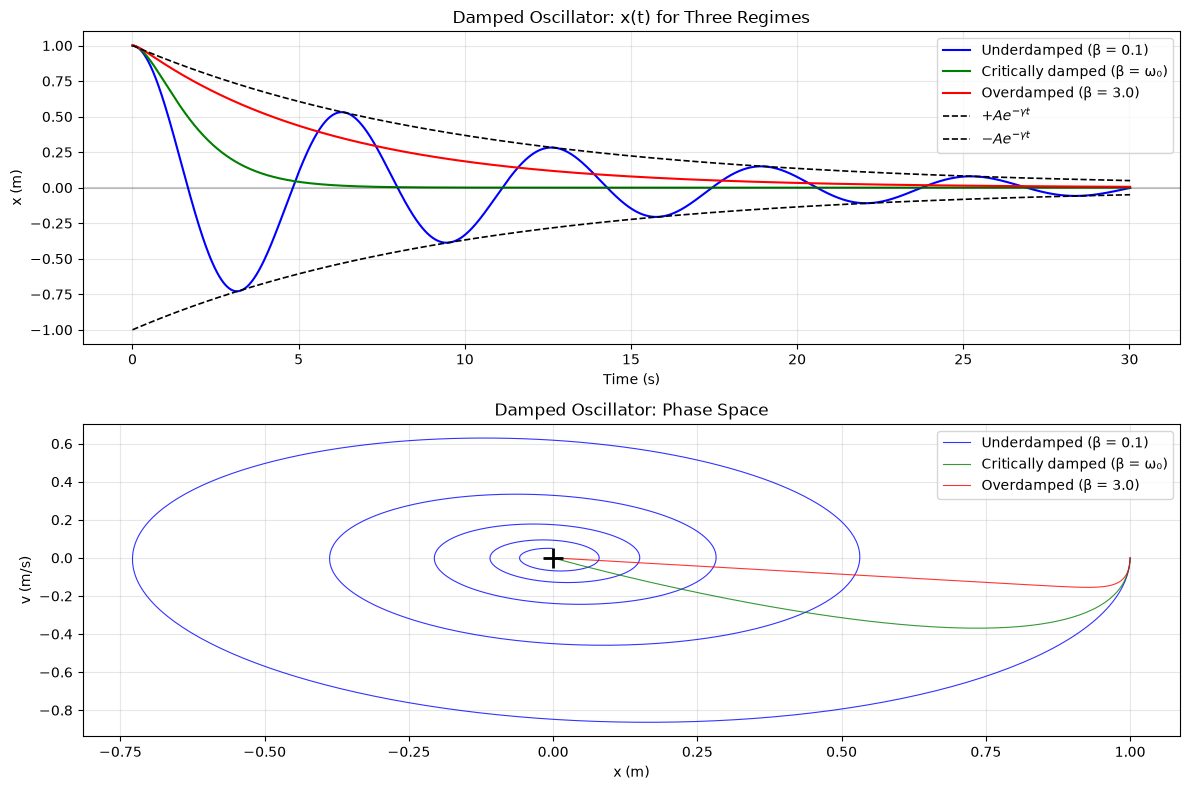

In [ ]:
def simulate_damped_sho(beta, dt=0.02, t_max=30.0):
    """Simulate damped SHO with Euler-Cromer.
    beta = b/(2m) is the damping parameter.
    """
    x, v = x0, v0
    b_damp = 2 * m * beta  # recover b from beta
    ts, xs, vs = [0], [x], [v]
    t = 0.0

    while t < t_max:
        # Force: spring + linear damping
        a = -(k / m) * x - (b_damp / m) * v

        # Euler-Cromer
        v = v + a * dt
        x = x + v * dt
        t += dt
        ts.append(t); xs.append(x); vs.append(v)

    return np.array(ts), np.array(xs), np.array(vs)

# ─── Compare three damping regimes ────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

regimes = [
    (0.1,  'Underdamped (β = 0.1)',   'b'),
    (omega0, 'Critically damped (β = ω₀)', 'g'),
    (3.0,  'Overdamped (β = 3.0)',     'r'),
]

for beta, label, color in regimes:
    t, x, v = simulate_damped_sho(beta)
    axes[0].plot(t, x, color=color, label=label, linewidth=1.5)
    axes[1].plot(x, v, color=color, label=label, linewidth=0.8, alpha=0.8)

# x(t) plot
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('x (m)')
axes[0].set_title('Damped Oscillator: x(t) for Three Regimes')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', alpha=0.2)

# Phase portrait
axes[1].set_xlabel('x (m)'); axes[1].set_ylabel('v (m/s)')
axes[1].set_title('Damped Oscillator: Phase Space')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].plot(0, 0, 'k+', markersize=15, markeredgewidth=2)  # equilibrium point

plt.tight_layout()


# Theoretical decay envelope for the underdamped case
beta_under = 0.1
t_under, x_under, v_under = simulate_damped_sho(beta_under)
A = x0
gamma = beta_under  # gamma = b/(2m) = beta
envelope = A * np.exp(-gamma * t_under)

axes[0].plot(
    t_under, envelope, 'k--',
    linewidth=1.2, label=r'$+Ae^{-\gamma t}$'
)
axes[0].plot(
    t_under, -envelope, 'k--',
    linewidth=1.2, label=r'$-Ae^{-\gamma t}$'
)
axes[0].legend()
plt.tight_layout()
plt.show()


### Part B.2 Results and Discussion

The code adds linear damping to the oscillator and uses the Euler-Cromer method to compare three damping regimes. The underdamped oscillator continues to oscillate while its amplitude decreases. The critically damped oscillator returns to equilibrium quickly without oscillating, while the overdamped oscillator returns more slowly.

For the underdamped oscillator, the theoretical amplitude envelope is $A e^{-\gamma t}$, where $\gamma=b/(2m)=\beta=0.1$. The simulated oscillation remains approximately within the two exponential envelope curves, showing that its amplitude follows the expected exponential decay. Small differences are caused by the finite time step and numerical approximation.

### Total Energy Tracking Analysis

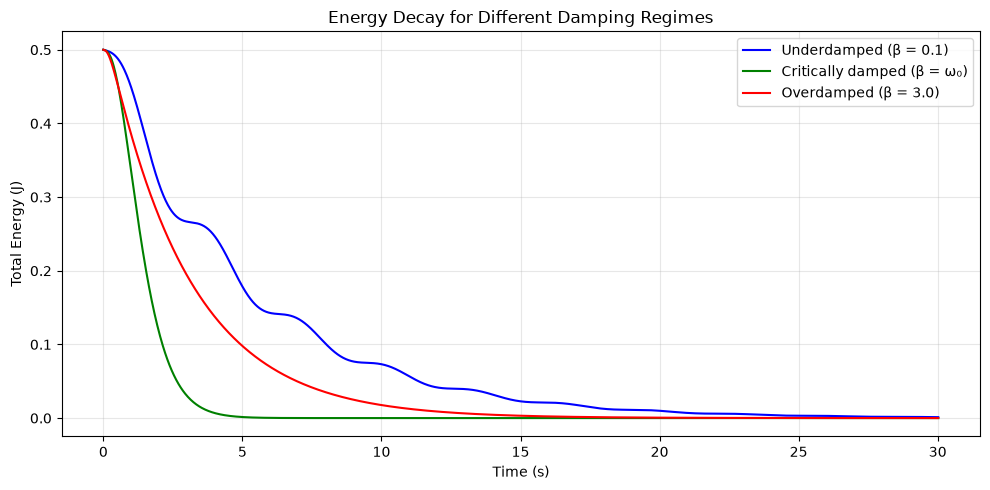

In [ ]:
# Track and compare total energy for each damping regime
fig, ax = plt.subplots(figsize=(10, 5))

energy_results = {}

for beta, label, color in regimes:
    t, x, v = simulate_damped_sho(beta)
    E = 0.5 * k * x**2 + 0.5 * m * v**2
    energy_results[label] = (t, E)

    ax.plot(t, E, color=color, label=label, linewidth=1.5)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Total Energy (J)')
ax.set_title('Energy Decay for Different Damping Regimes')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Energy Results and Discussion

The total energy decreases over time for all three damping regimes because energy is dissipated by the damping force. The overdamped oscillator loses energy most rapidly initially because it has the largest damping coefficient. The underdamped oscillator loses energy most slowly at first, while the critically damped oscillator lies between these cases.

### Part C — Driven Oscillations & Resonance
Periodic Driving Force Resonance: 
The driven damped oscillator is described by

$$
F = -kx - bv + F_0\cos(\omega_d t)
$$

The acceleration is:

$$
a = -\frac{k}{m}x - \frac{b}{m}v
    + \frac{F_0}{m}\cos(\omega_d t)
$$

beta = 0.05: predicted peak frequency = 0.997 rad/s
beta = 0.10: predicted peak frequency = 0.990 rad/s
beta = 0.30: predicted peak frequency = 0.906 rad/s


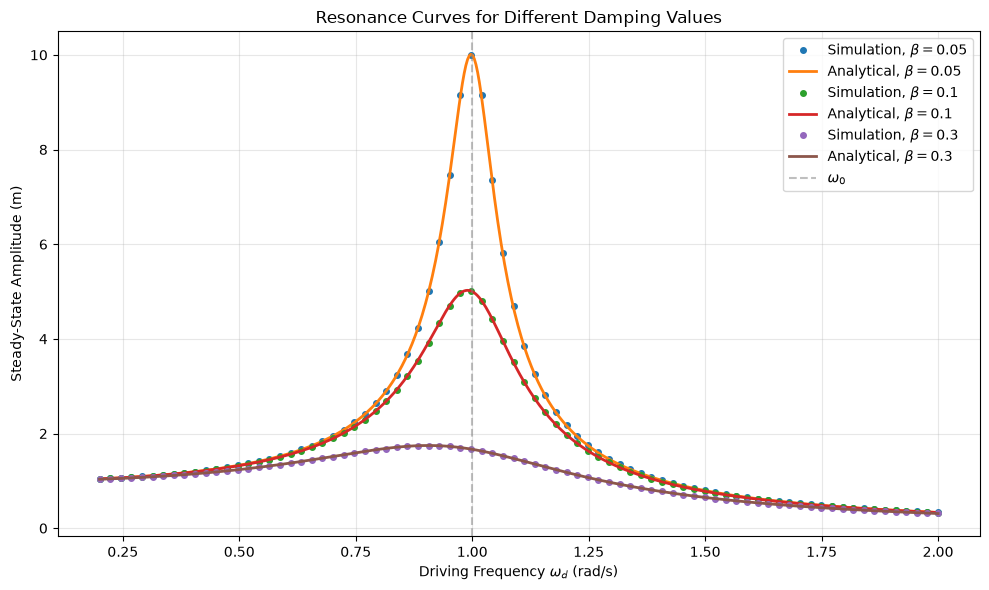

In [ ]:
def simulate_driven_sho(omega_d, F0, beta, dt=0.02, t_max=80.0):
    """Simulate driven, damped SHO with Euler-Cromer."""
    x, v = 0.0, 0.0
    b_damp = 2 * m * beta
    ts, xs = [0], [x]
    t = 0.0
    while t < t_max:
        a = (
            -(k / m) * x
            - (b_damp / m) * v
            + (F0 / m) * np.cos(omega_d * t)
        )

        v = v + a * dt
        x = x + v * dt

        t += dt
        ts.append(t)
        xs.append(x)

    return np.array(ts), np.array(xs)


beta_values = [0.05, 0.1, 0.3]
F0 = 1.0
omega_values = np.linspace(0.2, 2.0, 80)
omega_exact = np.linspace(0.2, 2.0, 500)

plt.figure(figsize=(10, 6))

for beta in beta_values:
    amplitudes = []

    for omega_d in omega_values:
        t, x = simulate_driven_sho(
            omega_d, F0, beta, dt=0.01, t_max=150.0
        )

        # Keeping only the final 30% to measure steady-state amplitude
        n = len(x)
        tail = x[int(0.7 * n):]
        amplitude = np.max(np.abs(tail))
        amplitudes.append(amplitude)

    plt.plot(
        omega_values,
        amplitudes,
        'o',
        markersize=4,
        label=fr'Simulation, $\beta={beta}$'
    )

    A_exact = (F0 / m) / np.sqrt(
        (omega0**2 - omega_exact**2)**2
        + (2 * beta * omega_exact)**2
    )

    plt.plot(
        omega_exact,
        A_exact,
        '-',
        linewidth=2,
        label=fr'Analytical, $\beta={beta}$'
    )

    omega_peak = np.sqrt(omega0**2 - 2 * beta**2)
    print(
        f"beta = {beta:.2f}: "
        f"predicted peak frequency = {omega_peak:.3f} rad/s"
    )

plt.xlabel(r'Driving Frequency $\omega_d$ (rad/s)')
plt.ylabel('Steady-State Amplitude (m)')
plt.title('Resonance Curves for Different Damping Values')
plt.axvline(
    omega0,
    color='gray',
    linestyle='--',
    alpha=0.5,
    label=r'$\omega_0$'
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Resonance Results and Discussion

As the damping parameter $\beta$ increases, the resonance peak becomes lower and broader. The lower peak height occurs because stronger damping removes more energy from the oscillator, reducing its steady-state amplitude. The increased damping also broadens the resonance curve, allowing a wider range of driving frequencies to produce a significant response.

The peak frequency shifts slightly below the natural frequency $\omega_0$. The analytical prediction for the peak location is

$$
\omega_{\mathrm{peak}} =
\sqrt{\omega_0^2 - 2\beta^2}.
$$

The numerical curves show the same trends predicted analytically: increasing damping decreases the peak height, increases the peak width, and shifts the peak location to a slightly lower frequency.

### Bonus Challenge — Nonlinear Pendulum: When the Textbook Formula Breaks

Everything above assumes the small-angle approximation, in which a pendulum behaves like a simple harmonic oscillator (SHO) with period

$$
T_{\mathrm{small}} = 2\pi\sqrt{\frac{L}{g}},
$$

independent of amplitude. The full nonlinear pendulum obeys

$$
\ddot{\theta} = -\frac{g}{L}\sin\theta.
$$

For large swings, $\sin\theta \neq \theta$, so the small-angle approximation fails. The period then increases with amplitude.

1. Simulate the full nonlinear pendulum using the Euler–Cromer method. Use $\sin(\theta)$ rather than $\theta$ in the acceleration.
2. Measure the numerical period for a small amplitude, such as $5^\circ$, and compare it with
   $$
   T_{\mathrm{small}} = 2\pi\sqrt{\frac{L}{g}}.
   $$
3. Measure the period for larger amplitudes, such as $30^\circ$, $90^\circ$, and $150^\circ$. Plot period versus amplitude.
4. In 2–3 sentences, explain how much the period increases and identify the amplitude at which the small-angle approximation differs by more than a few percent.

The simple pendulum equation is

$$
\alpha = \ddot{\theta}
= -\frac{g}{L}\sin\theta.
$$

For small angles measured in radians, $\sin\theta \approx \theta$, so the equation becomes

$$
\ddot{\theta} \approx -\frac{g}{L}\theta,
$$

which is the equation for a simple harmonic oscillator. For large angles, the full $\sin\theta$ term makes the motion nonlinear, and the period generally has no elementary closed-form solution.

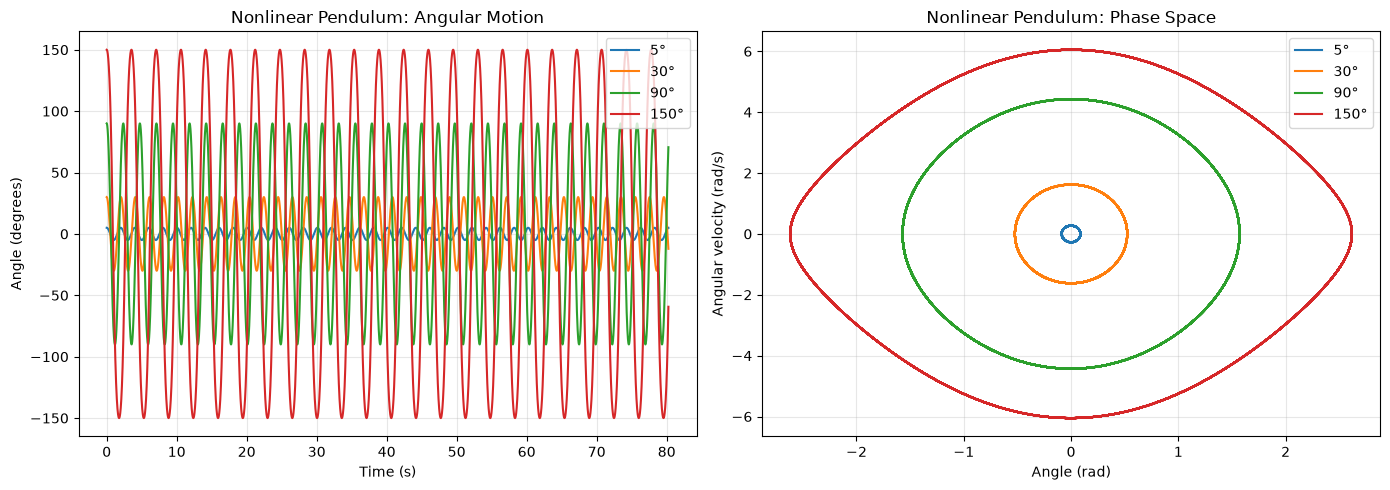

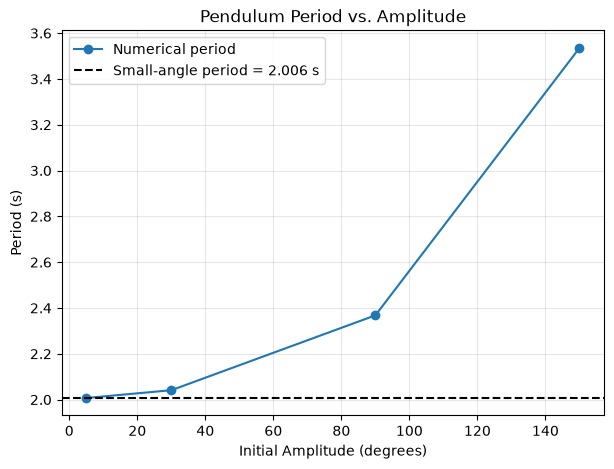

Small-angle period: 2.0061 s
  5°: period = 2.0070 s, difference = 0.05%
 30°: period = 2.0410 s, difference = 1.74%
 90°: period = 2.3678 s, difference = 18.03%
150°: period = 3.5351 s, difference = 76.22%

Difference at 5°: 0.05%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

g_val = 9.81
L = 1.0
m_pend = 1.0
T_small = 2 * np.pi * np.sqrt(L / g_val)


def simulate_pendulum(theta0_deg, dt=0.001, n_periods=5):
    """Nonlinear pendulum using Euler-Cromer."""
    theta = np.radians(theta0_deg)
    omega = 0.0
    t = 0.0
    t_max = n_periods * 8 * T_small

    ts = [t]
    thetas = [theta]
    omegas = [omega]

    while t < t_max:
        alpha = -(g_val / L) * np.sin(theta)

        omega += alpha * dt
        theta += omega * dt
        t += dt

        ts.append(t)
        thetas.append(theta)
        omegas.append(omega)

    ts = np.array(ts)
    thetas = np.array(thetas)
    omegas = np.array(omegas)

    kinetic = 0.5 * m_pend * (L * omegas) ** 2
    potential = m_pend * g_val * L * (1 - np.cos(thetas))
    energy = kinetic + potential

    return ts, thetas, omegas, energy


def measure_period(t, theta):
    """Measure period from successive downward zero crossings."""
    crossings = []

    for i in range(1, len(theta)):
        if theta[i - 1] > 0 and theta[i] <= 0:
            crossing_time = t[i - 1] - theta[i - 1] * (
                (t[i] - t[i - 1]) / (theta[i] - theta[i - 1])
            )
            crossings.append(crossing_time)

    if len(crossings) < 2:
        return np.nan

    return np.mean(np.diff(crossings))


angles = np.array([5, 30, 90, 150])
periods = []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for angle in angles:
    t, theta, omega, energy = simulate_pendulum(angle)

    periods.append(measure_period(t, theta))

    ax1.plot(t, np.degrees(theta), label=f"{angle}°")
    ax2.plot(theta, omega, label=f"{angle}°")

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Angle (degrees)")
ax1.set_title("Nonlinear Pendulum: Angular Motion")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.set_xlabel("Angle (rad)")
ax2.set_ylabel("Angular velocity (rad/s)")
ax2.set_title("Nonlinear Pendulum: Phase Space")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


periods = np.array(periods)

plt.figure(figsize=(7, 5))
plt.plot(angles, periods, "o-", label="Numerical period")
plt.axhline(T_small, color="k", linestyle="--",
            label=f"Small-angle period = {T_small:.3f} s")
plt.xlabel("Initial Amplitude (degrees)")
plt.ylabel("Period (s)")
plt.title("Pendulum Period vs. Amplitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


print(f"Small-angle period: {T_small:.4f} s")

for angle, period in zip(angles, periods):
    difference = 100 * (period - T_small) / T_small
    print(
        f"{angle:3d}°: period = {period:.4f} s, "
        f"difference = {difference:.2f}%"
    )

small_angle_difference = 100 * abs(periods[0] - T_small) / T_small
print(f"\nDifference at 5°: {small_angle_difference:.2f}%")

The small-angle prediction is $T_{\mathrm{small}}\approx 2.006$ s. The numerical period increases from approximately $2.010$ s at $5^\circ$ to $2.041$ s at $30^\circ$, $2.37$ s at $90^\circ$, and $3.54$ s at $150^\circ$. Thus, the period increases by about $76\%$ at $150^\circ$. The small-angle approximation differs by more than a few percent at approximately $40^\circ$–$45^\circ$ and becomes substantially inaccurate for amplitudes of $90^\circ$ or larger.
